In [16]:
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns

from afolu.assets.constants import LABEL_LIST
from afolu.assets.emissions import build_dataset, generate_model_objects
from pathlib import Path

In [17]:
data_path = Path(os.environ["DATA_PATH"])
out_path = data_path / "generated"

In [18]:
ZONE = "GUY+Georgetown"

In [19]:
df_out = (
    pd.read_csv(out_path / "small" / "emissions" / f"{ZONE}.csv")
    .query("time_period < 21")
    .set_index("time_period")
)

In [20]:
areas = pd.read_csv(out_path / "small" / "area" / "table_merged" / f"{ZONE}.csv")
transitions = pd.read_csv(out_path / "small" / "transition" / "cube" / f"{ZONE}.csv")
transitions_emissions = pd.read_csv(
    out_path / "small" / "transitions_emissions" / f"{ZONE}.csv"
).query("time_period < 21")

In [21]:
def emissions_small(
    areas: pd.DataFrame, transitions: pd.DataFrame, *, iso: str
) -> pd.DataFrame:
    # Initialize SISEPUEDE objects
    examples, _, model_afolu, regions, time_periods = generate_model_objects()

    temp = areas.set_index("label")

    areas_frac = temp.div(temp.sum(axis=0), axis=1).reset_index(names="label")

    # run model
    dict_ursa_data = {
        "areas": areas,
        "areas_frac": areas_frac,
        "transitions": transitions,
    }
    df_in = build_dataset(
        examples,
        iso,
        model_afolu,
        regions,
        time_periods,
        dict_ursa_data=dict_ursa_data,
        path_ssp_data=data_path / "initial" / "sisepuede_pipeline_data",
    )

    return model_afolu(
        df_in,
    ).set_index("time_period")

In [22]:
positive_lands = [
    "croplands",
    "forests_mangroves",
    "forests_primary",
    "forests_secondary",
    "flooded",
    "grasslands",
    "pastures",
    "shrublands",
    "wetlands",
]
negative_lands = list(set(LABEL_LIST) - set(positive_lands))

In [23]:
positive_max = (
    areas.set_index("label")
    .loc[[idx for idx in positive_lands if idx in areas["label"].values]]
    .max(axis=1)
)
negative_min = (
    areas.set_index("label")
    .loc[[idx for idx in negative_lands if idx in areas["label"].values]]
    .min(axis=1)
)
best = pd.concat([positive_max, negative_min])

areas_dummy = (
    pd.concat([best.rename(str(i)) for i in range(23)], axis=1)
    .sort_index()
    .reset_index()
)

In [24]:
transitions_dummy = transitions.copy()
for start_label in LABEL_LIST:
    for end_label in LABEL_LIST:
        col_name = f"pij_lndu_{start_label}_to_{end_label}"
        if start_label == end_label:
            transitions_dummy[col_name] = 1.0
        else:
            transitions_dummy[col_name] = 0.0

In [25]:
%%capture

df_dummy = emissions_small(areas_dummy, transitions_dummy, iso=ZONE.split("+")[0])
df_dummy = df_dummy.iloc[:21].copy()

In [26]:
sequestration_columns = [
    "emission_co2e_co2_lndu_biomass_sequestration_grasslands",
    "emission_co2e_co2_lndu_biomass_sequestration_other",
    "emission_co2e_co2_lndu_biomass_sequestration_pastures",
    "emission_co2e_co2_lndu_biomass_sequestration_settlements",
    "emission_co2e_co2_lndu_biomass_sequestration_shrublands",
    "emission_co2e_co2_lndu_biomass_sequestration_wetlands",
    "emission_co2e_subsector_total_frst",
]

In [27]:
ideal_sequestration = df_dummy[sequestration_columns].sum(axis=1).abs()
actual_sequestration = df_out[sequestration_columns].sum(axis=1).abs()

sequestration_oppportunity_cost = ideal_sequestration - actual_sequestration
sequestration_oppportunity_cost.index = (
    (sequestration_oppportunity_cost.index + 2000).astype(int).astype(str)
)

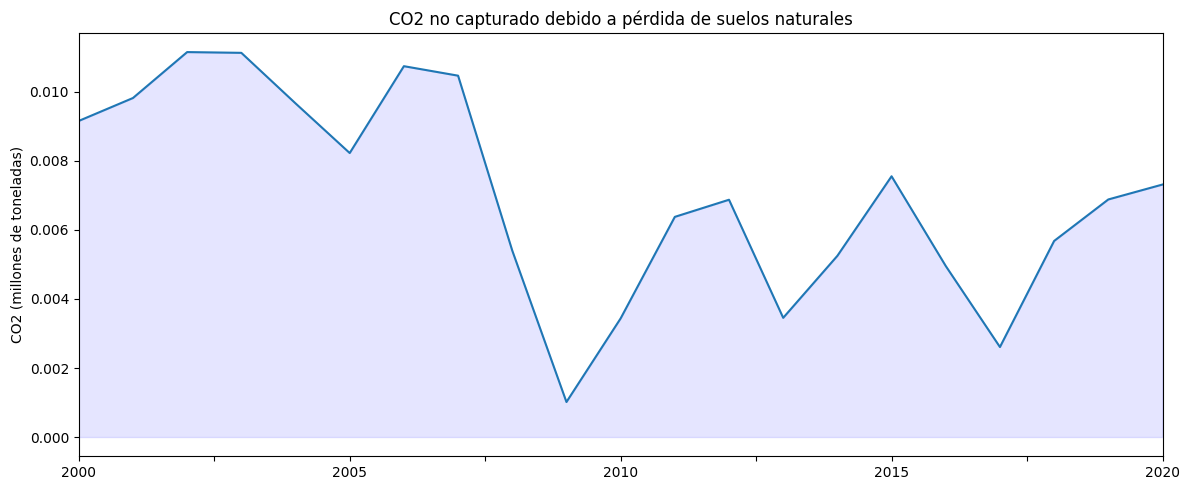

In [31]:
fig, ax = plt.subplots(figsize=(12, 5))
sequestration_oppportunity_cost.plot(ax=ax)
ax.set_xlabel("")
ax.set_ylabel("CO2 (millones de toneladas)")
ax.set_title("CO2 no capturado debido a pérdida de suelos naturales")
ax.fill_between(
    sequestration_oppportunity_cost.index,
    sequestration_oppportunity_cost,
    alpha=0.1,
    color="blue",
)
ax.set_xlim("2000", "2020")
# ax.set_ylim(0, 22)
fig.tight_layout()

C:\Users\lain\AppData\Local\Temp\ipykernel_37944\708067544.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  areas.set_index("label").loc["settlements"][list(range(21))].plot(label="Área urbanizada", ax=ax, c="r")


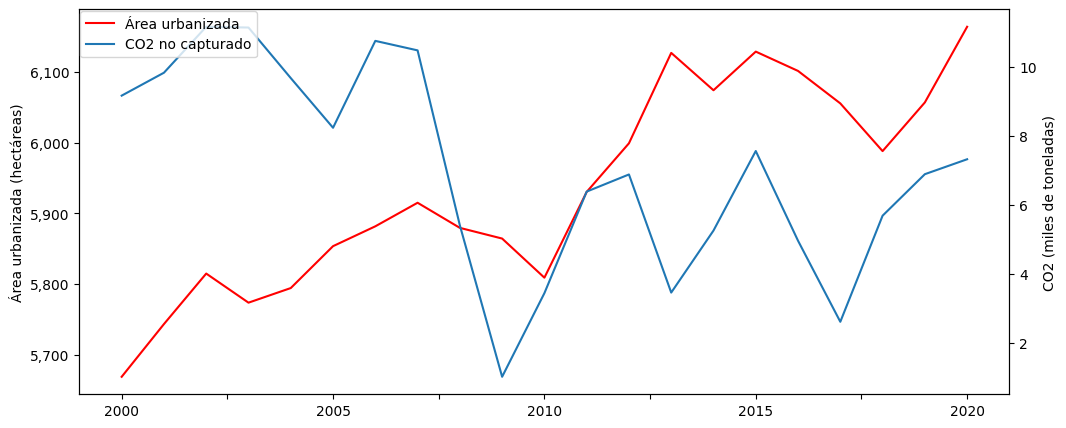

In [32]:
fig, ax = plt.subplots(figsize=(12, 5))
areas.set_index("label").loc["settlements"][list(range(21))].plot(
    label="Área urbanizada", ax=ax, c="r"
)

ax2 = ax.twinx()
sequestration_oppportunity_cost.multiply(1000).plot(label="CO2 no capturado", ax=ax2)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

ax.set_ylabel("Área urbanizada (hectáreas)")
ax2.set_ylabel("CO2 (miles de toneladas)")

fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.89))

In [33]:
c1 = (
    areas.set_index("label")
    .loc["settlements"][list(range(21))]
    .rename("urbanized_area_ha")
)
c1.index = c1.index.astype(int) + 2000

c2 = sequestration_oppportunity_cost.multiply(1000).rename("co2_not_captured_kt")
c2.index = c2.index.astype(int)

df_out = pd.concat([c1, c2], axis=1)
df_out.to_csv("./parallel.csv")

C:\Users\lain\AppData\Local\Temp\ipykernel_37944\272743121.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  c1 = areas.set_index("label").loc["settlements"][list(range(21))].rename("urbanized_area_ha")
